# Co-brand association: do people link Lenovo with FIFA more than other brands?

**Review notebook** for `cobrand_placebo_v1` (ADR-0035). It follows the human-review standard in `AGENTS.md`.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in. The Trends pull is NOT re-run here (it calls Google); only the test is recomputed.
    subprocess.run([sys.executable, "-m", "srmp.experiments.cobrand_placebo_v1"], check=True)

C = "data/curated/experimental/cobrand_placebo_v1/"
SOURCES = [
    "config/cobrand_placebo_trends.yaml", "config/experiments/cobrand_placebo_v1.yaml",
    "data/curated/trends/cobrand_placebo_trends.parquet",
    "data/staged/trends_cobrand_placebos/anchor_scale_factors.csv",
    C + "cobrand_placebo_manifest.json", C + "placebo_tests.parquet", C + "log_changes.parquet",
    C + "lenovo_property_comparison.parquet",
]
stamp_sources(SOURCES)

REVIEW_SOURCES={"config/cobrand_placebo_trends.yaml": "bf0f5e9f8fadcf476535d51203751f3272f54a212febefddc09acd427840f777", "config/experiments/cobrand_placebo_v1.yaml": "4e14586ca70ba2a3de2531516fe01fbab14c7cb42fe9d005fe03574fd2768210", "data/curated/trends/cobrand_placebo_trends.parquet": "0dcc0e839fbd87a52db04538a94b971d13d982b0f7f9154d3e1a15a8e9e77795", "data/staged/trends_cobrand_placebos/anchor_scale_factors.csv": "515f72347694f21bd009c7b8f97460a3adc44cfd334c1eba15464d707e791d2b", "data/curated/experimental/cobrand_placebo_v1/cobrand_placebo_manifest.json": "3597c436e0ad758c5a86827cf0901ff2cfcac7b37308fd73032f3b42afb65959", "data/curated/experimental/cobrand_placebo_v1/placebo_tests.parquet": "7b1aa3fff1bd2a82dd45967a66aca6e1b21e84a216cf2d39f7f5acd7cac61640", "data/curated/experimental/cobrand_placebo_v1/log_changes.parquet": "ae866806b4dc4cdf4c5f381f88be09c70e4e7af36fffb2735074352719345f5a", "data/curated/experimental/cobrand_placebo_v1/lenovo_property_comparison.parquet": "5d4365

,file,sha256,last_generated_utc,size_kb
0,config/cobrand_placebo_trends.yaml,bf0f5e9f8fad,NaN,2.8
1,config/experiments/cobrand_placebo_v1.yaml,4e14586ca70b,NaN,1.6
2,data/curated/trends/cobrand_placebo_trends.par...,0dcc0e839fbd,NaN,12.7
3,data/staged/trends_cobrand_placebos/anchor_sca...,515f72347694,NaN,1.9
4,data/curated/experimental/cobrand_placebo_v1/c...,3597c436e0ad,2026-10-06T13:24:40.453230+00:00,3.6
5,data/curated/experimental/cobrand_placebo_v1/p...,7b1aa3fff1bd,NaN,6.1
6,data/curated/experimental/cobrand_placebo_v1/l...,ae866806b4dc,NaN,5.2
7,data/curated/experimental/cobrand_placebo_v1/l...,5d4365f2bf4f,NaN,3.7


## 1. Question and purpose

**Question.** After the partnership was announced, and especially around the 2026 World Cup, did people search for "Lenovo FIFA" or "Lenovo World Cup" more than they searched for the same terms with brands that are *not* FIFA sponsors?

**Why it matters.** A sponsorship's first job is to create an association between the brand and the property. Searches combining the two terms are a direct, observable trace of that association. Earlier in the project the roughly tenfold rise in "Lenovo FIFA" searches was read as the clearest uplift; this test checks whether that rise is specific to Lenovo.

**Objective supported.** Separating a sponsorship-specific association effect from the general surge of World Cup interest.

## 2. Evidence and inputs

| Input | What it is | Source | Label |
|---|---|---|---|
| "Lenovo FIFA", "Lenovo World Cup" | Treated search queries | Google Trends, worldwide | **observed** |
| "<brand> FIFA", "<brand> World Cup" for 11–12 non-sponsor tech brands | Placebo queries (Dell, HP, Asus, Acer, MSI, Apple, Microsoft, Razer, Sony, Xiaomi, Huawei, Intel) | Google Trends | **observed** |
| Common anchor | Every panel includes "Lenovo FIFA" so all queries share one scale | Google Trends panels, 10 draws each | **constructed** (rescaled) |
| Lenovo's other sponsorships | "Lenovo F1", "Lenovo MotoGP", "Lenovo Ducati" (separately normalised) | Google Trends | **observed** |

Coverage: 2022-01-01 to the 5 October 2026 pull; the last two weeks are provisional and excluded.

In [2]:
scale = pd.read_csv("data/staged/trends_cobrand_placebos/anchor_scale_factors.csv")
summary = scale.groupby("panel_id").agg(draws=("draw", "nunique"), anchor_overlap_weeks=("anchor_overlap_weeks", "min"),
                                         scale_factor_min=("anchor_scale_factor", "min"), scale_factor_max=("anchor_scale_factor", "max"))
display(summary.rename(columns={"draws": "Draws", "anchor_overlap_weeks": "Weeks used to rescale",
                                "scale_factor_min": "Scale factor (min)", "scale_factor_max": "Scale factor (max)"}).style.format(precision=3))
md("**Table 1.** Rescaling diagnostics. Each panel is mapped onto the first panel's 'Lenovo FIFA' path using weeks where both are above zero. "
   f"The thinnest panel rescales on {int(summary['anchor_overlap_weeks'].min())} weeks (its large 'Apple/Microsoft World Cup' queries push "
   "'Lenovo FIFA' below 1 in most other weeks); its placebos are therefore less precisely scaled.")

,Draws,Weeks used to rescale,Scale factor (min),Scale factor (max)
panel_id,,,,
fifa_a,10,98,1.000,1.000
fifa_b,10,46,4.639,4.639
fifa_c,10,98,0.987,0.987
worldcup_a,10,71,1.819,1.819
worldcup_b,10,17,9.694,9.694
worldcup_c,10,70,1.892,1.892


**Table 1.** Rescaling diagnostics. Each panel is mapped onto the first panel's 'Lenovo FIFA' path using weeks where both are above zero. The thinnest panel rescales on 17 weeks (its large 'Apple/Microsoft World Cup' queries push 'Lenovo FIFA' below 1 in most other weeks); its placebos are therefore less precisely scaled.

## 3. Method and formulas

For each query $q$ and test window $W$, the statistic is the log change from a pre-announcement baseline $B$ (the 52 weeks to 13 October 2024, after EA renamed its FIFA video game to EA FC, so game searches do not distort the baseline):

$$\ell_q(W) = \ln\frac{\bar s_q(W) + c}{\bar s_q(B) + c},$$

where $\bar s_q$ is the mean common-scale search interest over the window and $c = 1$ is a floor that keeps near-zero queries finite. *In words:* by what factor did searches for this brand-plus-FIFA term rise from the year before the announcement to the window, with $e^{\ell}$ the multiple.

The one-sided placebo p-value ranks Lenovo among the non-sponsors:

$$p = \frac{1 + \#\{\text{placebos with } \ell_j \ge \ell_{Lenovo}\}}{1 + J}.$$

*In words:* the share of comparable brands whose association searches rose at least as much as Lenovo's. Windows: after the announcement but before the World Cup, the tournament, and after the final. The design (queries, baseline, windows, floor) was fixed before the data were downloaded.

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Pull six common-anchor panels | `srmp/ingest/trends_joint.py` (`pull_joint_trends`) | `config/cobrand_placebo_trends.yaml` | `data/raw/trends_cobrand_placebos/`, `data/curated/trends/cobrand_placebo_trends.parquet` |
| Log changes, placebo ranks, Lenovo property comparison | `srmp/experiments/cobrand_placebo_v1.py` (`log_changes`, `build_cobrand_placebo`) | `config/experiments/cobrand_placebo_v1.yaml` | `data/curated/experimental/cobrand_placebo_v1/` |

## 5. Results

In [3]:
tests = pd.read_parquet(C + "placebo_tests.parquet")
show = tests.assign(multiple=lambda t: t["treated_multiple"], placebo_median_multiple=lambda t: np.exp(t["placebo_median_log_change"]))
show = show[["construct", "window", "multiple", "placebo_median_multiple", "placebos", "p_value", "significant"]].rename(columns={
    "construct": "Search term", "window": "Window", "multiple": "Lenovo rise (×)", "placebo_median_multiple": "Non-sponsor median rise (×)",
    "placebos": "Placebo brands", "p_value": "p-value (one-sided)", "significant": "p ≤ 0.10"})
display(show.style.format({"Lenovo rise (×)": "{:.1f}", "Non-sponsor median rise (×)": "{:.1f}", "p-value (one-sided)": "{:.3f}"}).hide(axis="index"))
md(f"**Table 2.** Rise from the pre-announcement baseline. Lenovo's association searches rose in every window, "
   f"but so did everyone's; Lenovo's p-values range {tests['p_value'].min():.2f}–{tests['p_value'].max():.2f}. "
   f"{'No' if not tests['significant'].any() else 'Some'} window is significant.")

Search term,Window,Lenovo rise (×),Non-sponsor median rise (×),Placebo brands,p-value (one-sided),p ≤ 0.10
fifa,post_announcement_pre_world_cup,2.9,2.4,12,0.231,False
fifa,world_cup_tournament,42.3,37.4,12,0.385,False
fifa,after_the_final,5.9,4.1,12,0.231,False
world_cup,post_announcement_pre_world_cup,3.3,3.2,11,0.500,False
world_cup,world_cup_tournament,58.8,60.4,11,0.583,False
world_cup,after_the_final,5.7,5.3,11,0.417,False


**Table 2.** Rise from the pre-announcement baseline. Lenovo's association searches rose in every window, but so did everyone's; Lenovo's p-values range 0.23–0.58. No window is significant.

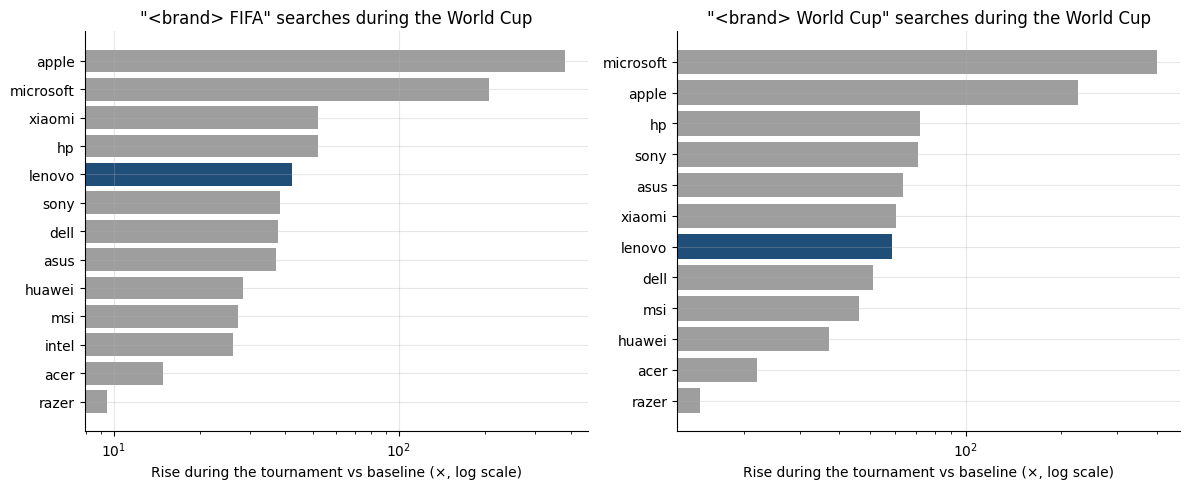

**Figure 1.** Blue: Lenovo. Every brand's FIFA and World Cup searches surged during the tournament; Apple and Microsoft rose far more than Lenovo, which sits in the middle of the non-sponsors.

In [4]:
changes = pd.read_parquet(C + "log_changes.parquet")
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, (construct, treated, prefix) in zip(axes, [("FIFA", "cobrand_lenovo_fifa", "fifa_"), ("World Cup", "worldcup_lenovo", "worldcup_")]):
    sub = changes[changes["window"].eq("world_cup_tournament") & (changes["query_id"].str.startswith(prefix) | changes["query_id"].eq(treated))]
    sub = sub.assign(label=sub["query_id"].str.replace(prefix, "").str.replace("cobrand_lenovo_fifa", "lenovo")).sort_values("log_change")
    ax.barh(sub["label"], np.exp(sub["log_change"]), color=["#1f4e79" if "lenovo" in q else "#9e9e9e" for q in sub["query_id"]])
    ax.set_xscale("log"); ax.set_xlabel("Rise during the tournament vs baseline (×, log scale)")
    ax.set_title(f'"<brand> {construct}" searches during the World Cup')
plt.tight_layout(); plt.show()
md("**Figure 1.** Blue: Lenovo. Every brand's FIFA and World Cup searches surged during the tournament; Apple and Microsoft rose far more "
   "than Lenovo, which sits in the middle of the non-sponsors.")

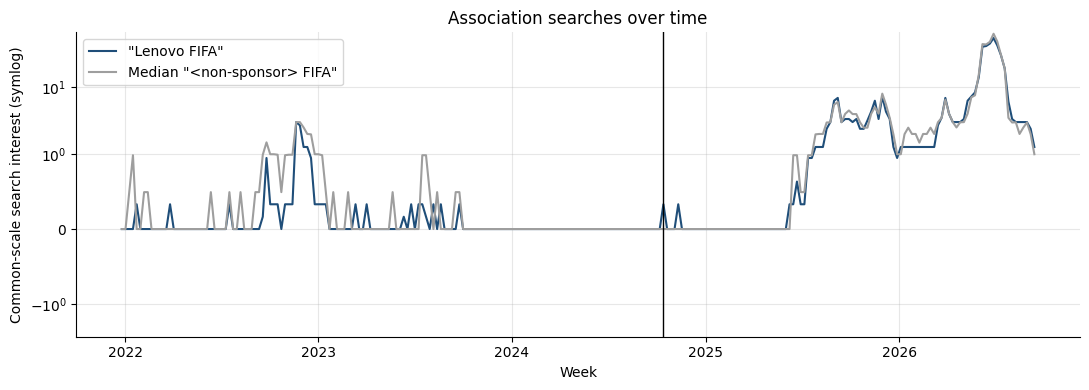

**Figure 2.** Vertical line: announcement. Mean common-scale interest, Lenovo vs non-sponsor median: Club World Cup 2025 0.5 vs 0.7; Men's World Cup 2026 38.1 vs 41.4. After the announcement Lenovo is above the non-sponsor median in 27% of weeks, i.e. more often below than above the typical non-sponsor brand. Table 2 tests the *rise* from the pre-announcement baseline, which is what a new association would change.

In [5]:
panel = pd.read_parquet("data/curated/trends/cobrand_placebo_trends.parquet")
panel["week"] = pd.to_datetime(panel["week"])
wide = panel.groupby(["week", "query_id"])["interest_common_scale"].mean().unstack().iloc[:-2]
fifa_placebos = [c for c in wide.columns if c.startswith("fifa_")]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wide.index, wide["cobrand_lenovo_fifa"], color="#1f4e79", label='"Lenovo FIFA"')
ax.plot(wide.index, wide[fifa_placebos].median(axis=1), color="#9e9e9e", label='Median "<non-sponsor> FIFA"')
ax.axvline(pd.Timestamp("2024-10-13"), color="black", lw=1)
ax.set_yscale("symlog", linthresh=1); ax.set_ylabel("Common-scale search interest (symlog)"); ax.set_xlabel("Week")
ax.set_title("Association searches over time"); ax.legend(); plt.tight_layout(); plt.show()
median = wide[fifa_placebos].median(axis=1)
def window_mean(series, a, b): return series[(series.index >= a) & (series.index <= b)].mean()
cwc = (window_mean(wide["cobrand_lenovo_fifa"], "2025-06-08", "2025-07-13"), window_mean(median, "2025-06-08", "2025-07-13"))
wc = (window_mean(wide["cobrand_lenovo_fifa"], "2026-06-07", "2026-07-19"), window_mean(median, "2026-06-07", "2026-07-19"))
post = wide.index > pd.Timestamp("2024-10-13")
share_above = float((wide.loc[post, "cobrand_lenovo_fifa"] > median[post]).mean())
md(f"**Figure 2.** Vertical line: announcement. Mean common-scale interest, Lenovo vs non-sponsor median: Club World Cup 2025 "
   f"{cwc[0]:.1f} vs {cwc[1]:.1f}; Men's World Cup 2026 {wc[0]:.1f} vs {wc[1]:.1f}. After the announcement Lenovo is above the "
   f"non-sponsor median in {100*share_above:.0f}% of weeks, i.e. "
   f"{'more often above than below' if share_above > 0.5 else 'more often below than above'} the typical non-sponsor brand. "
   "Table 2 tests the *rise* from the pre-announcement baseline, which is what a new association would change.")

In [6]:
props = pd.read_parquet(C + "lenovo_property_comparison.parquet")
display(props.pivot(index="query_id", columns="window", values="log_change").pipe(np.exp).rename_axis("Lenovo co-brand query")
        .style.format("{:.1f}×"))
md("**Table 3.** Within Lenovo's own sponsorships (separately normalised queries, so only the multiples are comparable). "
   "'Lenovo FIFA' rose far more than 'Lenovo F1' or 'Lenovo MotoGP', but Table 2 shows that is the World Cup tide, not a Lenovo-specific effect.")

window,after_the_final,post_announcement_pre_world_cup,world_cup_tournament
Lenovo co-brand query,,,
cobrand_ducati,1.3×,1.5×,2.3×
cobrand_f1,2.6×,2.8×,3.1×
cobrand_fifa,6.4×,3.2×,48.0×
cobrand_motogp,1.3×,1.7×,2.4×


**Table 3.** Within Lenovo's own sponsorships (separately normalised queries, so only the multiples are comparable). 'Lenovo FIFA' rose far more than 'Lenovo F1' or 'Lenovo MotoGP', but Table 2 shows that is the World Cup tide, not a Lenovo-specific effect.

## 6. Interpretation

In [7]:
t = tests.set_index(["construct", "window"])
md(f"""- **Direction:** Lenovo's association searches rose strongly ({t.loc[('fifa','world_cup_tournament'),'treated_multiple']:.0f}× during the tournament for "Lenovo FIFA").
- **Relative to non-sponsors:** not unusual. Non-sponsor brands' FIFA searches rose by a median {np.exp(t.loc[('fifa','world_cup_tournament'),'placebo_median_log_change']):.0f}×; Lenovo's p = {t.loc[('fifa','world_cup_tournament'),'p_value']:.2f}.
- **Meaning:** the earlier reading of a tenfold rise as a sponsorship association effect is withdrawn. It reflects the general World Cup search tide that lifted every brand's FIFA-related queries.
- **Decision relevance:** search data provide no evidence of a *distinctive* Lenovo–FIFA association. Association should be measured with survey questions (sponsor recall and attribution) rather than search.""")

- **Direction:** Lenovo's association searches rose strongly (42× during the tournament for "Lenovo FIFA").
- **Relative to non-sponsors:** not unusual. Non-sponsor brands' FIFA searches rose by a median 37×; Lenovo's p = 0.38.
- **Meaning:** the earlier reading of a tenfold rise as a sponsorship association effect is withdrawn. It reflects the general World Cup search tide that lifted every brand's FIFA-related queries.
- **Decision relevance:** search data provide no evidence of a *distinctive* Lenovo–FIFA association. Association should be measured with survey questions (sponsor recall and attribution) rather than search.

## 7. Limitations and non-claims

- **Search ≠ association.** Searches combining a brand with "FIFA" can reflect gaming, streaming, retail or news, not only sponsorship recall. Apple's and Microsoft's rises likely reflect streaming and gaming.
- **Not proof of no association.** The test finds no *search* signal specific to Lenovo; awareness surveys (which show aware–unaware gaps of 28–48 points, observational) may still capture an association.
- **Scaling precision.** One placebo panel rescales on 17 weeks; its brands' changes are less precise.
- **Global aggregate.** Worldwide searches can mask country-level association effects.
- **Sampling.** Google Trends is sampled and rounded; ten draws per panel reduce but do not remove this noise, which the rank test does not capture.

## Next steps

Add sponsor-recall and sponsor-attribution questions ("Which brands sponsor the FIFA World Cup?") to the post-World Cup survey wave.